In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dropout
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping

In [24]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=2)

<Axes: >

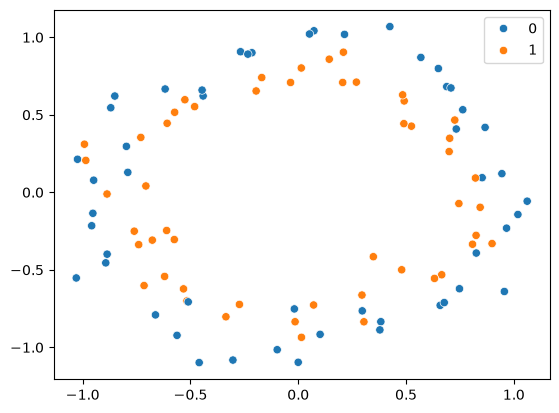

In [25]:
sns.scatterplot(x = X[:,0],y = X[:,1],hue=y)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [28]:
model = Sequential()

model.add(Input(shape = (2,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=200, verbose=1)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.4875 - loss: 0.6921 - val_accuracy: 0.4500 - val_loss: 0.6935
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5125 - loss: 0.6894 - val_accuracy: 0.4500 - val_loss: 0.6965
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5125 - loss: 0.6880 - val_accuracy: 0.4500 - val_loss: 0.7001
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5125 - loss: 0.6866 - val_accuracy: 0.4500 - val_loss: 0.7035
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5125 - loss: 0.6847 - val_accuracy: 0.4500 - val_loss: 0.7068
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5125 - loss: 0.6843 - val_accuracy: 0.4500 - val_loss: 0.7109
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5125 - loss: 0.6828 - val_accuracy: 0.4500 - val_loss: 0.7140
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5125 - loss: 0.6826 - val_accuracy: 0.4500 - val_loss

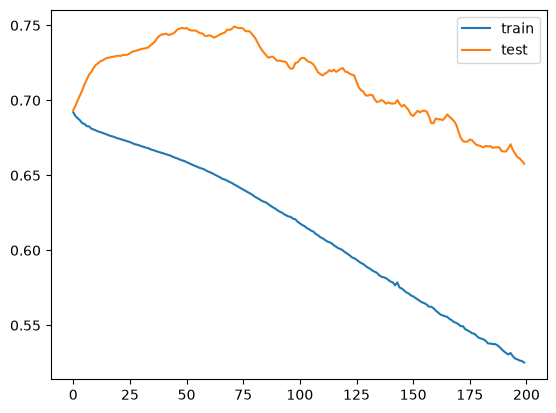

In [29]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

# Using Early Stopping

In [30]:
model = Sequential()

model.add(Input(shape = (2,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [31]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.0000001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [32]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=200, callbacks=callback)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.5125 - loss: 0.6951 - val_accuracy: 0.4500 - val_loss: 0.7005
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4875 - loss: 0.6931 - val_accuracy: 0.3500 - val_loss: 0.7042
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5125 - loss: 0.6904 - val_accuracy: 0.3500 - val_loss: 0.7063
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.6895 - val_accuracy: 0.4000 - val_loss: 0.7088
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5375 - loss: 0.6881 - val_accuracy: 0.3000 - val_loss: 0.7114
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5500 - loss: 0.6874 - val_accuracy: 0.3000 - val_loss: 0.7136
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5500 - loss: 0.6862 - val_accuracy: 0.3000 - val_loss: 0.7153
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5625 - loss: 0.6856 - val_accuracy: 0.3000 - val_loss

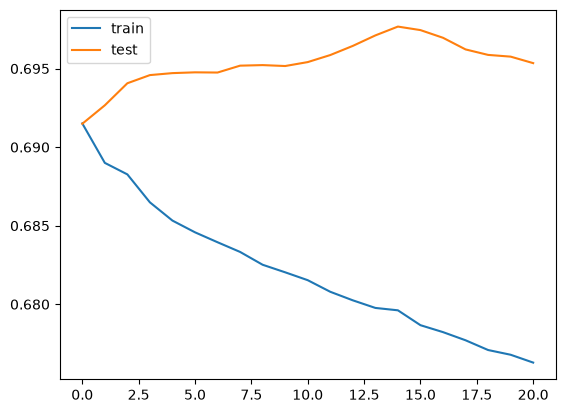

In [23]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()